# Crime Data Analysis of Women in India
Analysis of crimes against women across different states and years to identify patterns, major crime categories, and long-term trends.

## Dataset Description

The dataset contains crime records related to women across different states in India over multiple years.  
Each record includes the state name, year, and counts of different crime categories such as rape, kidnapping & abduction, domestic violence, and other offenses.

## Dataset Exploration

This section loads the dataset and performs initial exploration to understand the structure of the data, including column names, data types, and sample records.

In [58]:
import pandas as pd

data = pd.read_csv("crime_data.csv")

data.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [59]:
data.columns

Index(['Unnamed: 0', 'State', 'Year', 'Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV',
       'WT'],
      dtype='object')

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
Unnamed: 0    736 non-null int64
State         736 non-null object
Year          736 non-null int64
Rape          736 non-null int64
K&A           736 non-null int64
DD            736 non-null int64
AoW           736 non-null int64
AoM           736 non-null int64
DV            736 non-null int64
WT            736 non-null int64
dtypes: int64(9), object(1)
memory usage: 57.6+ KB


## Data Cleaning

The dataset contains an unnecessary index column. This section removes the extra column to prepare the dataset for analysis.

In [61]:
data = data.drop(columns=["Unnamed: 0"])
data.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,ASSAM,2001,817,1070,59,850,4,1248,0
3,BIHAR,2001,888,518,859,562,21,1558,83
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [ ]:
state_crime = data.groupby("State").sum()
state_crime.head()

,Year,Rape,K&A,DD,AoW,AoM,DV,WT
State,,,,,,,,
A & N ISLANDS,20055,84,58,4,182,36,111,0
A & N Islands,22176,340,305,9,376,99,254,10
ANDHRA PRADESH,20055,10696,11921,5112,42334,28759,92242,17
ARUNACHAL PRADESH,20055,412,440,1,666,16,123,0
ASSAM,20055,12762,16368,1015,10587,99,27735,4


## Crime Totals by State

This analysis groups the dataset by state and calculates the total crimes across all crime categories to identify which states report the highest crime incidents.

In [63]:
state_crime["Total Crime"] = state_crime.sum(axis=1)

state_crime.head()

,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total Crime
State,,,,,,,,,
A & N ISLANDS,20055,84,58,4,182,36,111,0,20530
A & N Islands,22176,340,305,9,376,99,254,10,23569
ANDHRA PRADESH,20055,10696,11921,5112,42334,28759,92242,17,211136
ARUNACHAL PRADESH,20055,412,440,1,666,16,123,0,21713
ASSAM,20055,12762,16368,1015,10587,99,27735,4,88625


## Total Crime Calculation

To understand overall crime levels, the analysis combines all crime categories into a single total crime value for each state.

In [64]:
state_crime = state_crime.sort_values("Total Crime", ascending=False)

state_crime.head()

,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total Crime
State,,,,,,,,,
Uttar Pradesh,22176,30641,101701,21357,76654,20024,100227,330,373110
West Bengal,22176,13108,37848,4006,33851,4952,171204,838,287983
Madhya Pradesh,22176,43552,50457,5834,85442,13850,63272,387,284970
Rajasthan,22176,31850,36059,3695,41801,2038,126917,662,265198
Maharashtra,22176,24806,38061,2175,76029,20948,67545,2531,254271


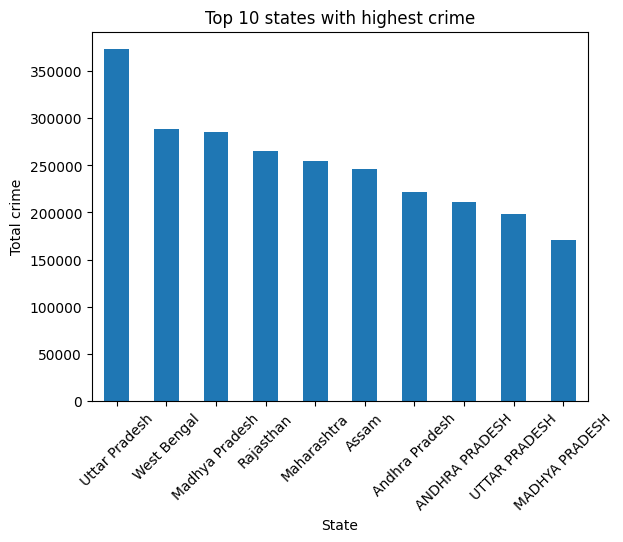

In [65]:
import matplotlib.pyplot as plt 

state_crime["Total Crime"].head(10).plot(kind = "bar")
plt.title("Top 10 states with highest crime")
plt.xlabel("State")
plt.ylabel("Total crime")
plt.xticks(rotation=45)
plt.show()


In [66]:
up_data = data[data["State"] == "Uttar Pradesh"]
up_data.head()
up_total = up_data.sum(numeric_only=True)
up_total

Year     22176
Rape     30641
K&A     101701
DD       21357
AoW      76654
AoM      20024
DV      100227
WT         330
dtype: int64

## Kidnapping & Abduction Analysis

Kidnapping and Abduction (K&A) is analyzed separately to understand its contribution to overall crimes and compare its occurrence across different states.

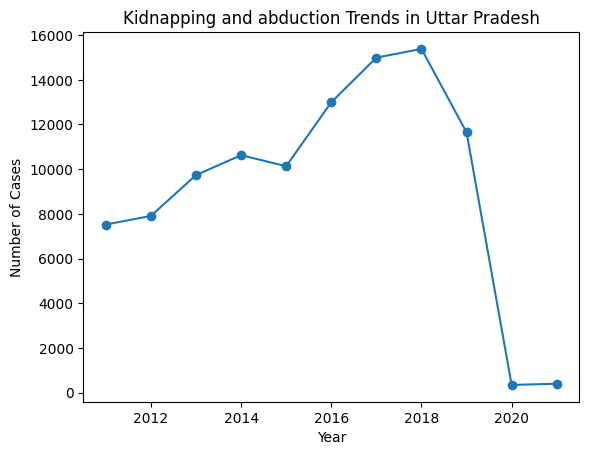

In [67]:
import matplotlib.pyplot as plt
plt.plot(up_data["Year"], up_data["K&A"], marker = "o")
plt.title ("Kidnapping and abduction Trends in Uttar Pradesh")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.show()


In [68]:
ka_by_state =data.groupby("State")["K&A"].sum()
ka_by_state = ka_by_state.sort_values(ascending=False)
ka_by_state.head(10)

State
Uttar Pradesh     101701
Bihar              65137
Assam              55094
Madhya Pradesh     50457
Maharashtra        38061
West Bengal        37848
Rajasthan          36059
UTTAR PRADESH      32155
Delhi UT           31251
Haryana            25097
Name: K&A, dtype: int64

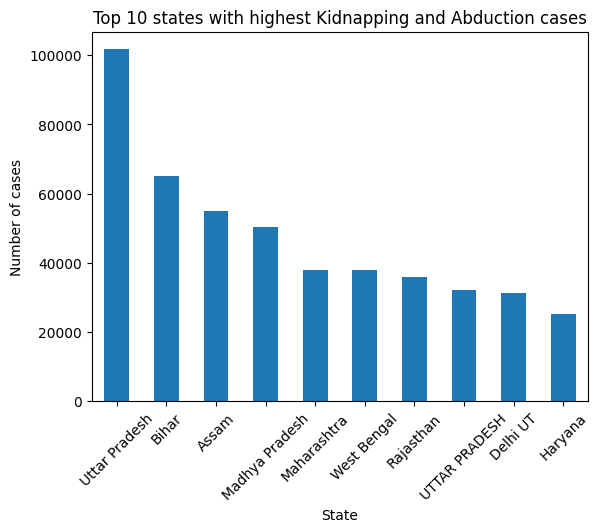

In [69]:
ka_by_state.head(10).plot(kind = "bar")
plt.title("Top 10 states with highest Kidnapping and Abduction cases")
plt.xlabel("State")
plt.ylabel("Number of cases")
plt.xticks(rotation=45)
plt.show()


## Crime Trend Visualization

A line chart is used to visualize how total crimes change across years, helping identify whether crime is increasing, decreasing, or fluctuating over time.

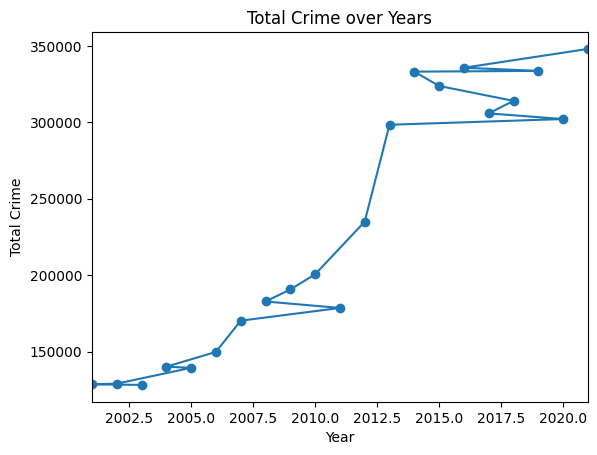

In [78]:

year_crime["Total Crime"].plot(kind = "line", marker = "o")

plt.title ("Total Crime over Years")
plt.xlabel("Year")
plt.ylabel("Total Crime")

plt.show()

## Crime Trend Over Years

This section analyzes how crime incidents change over time by grouping data by year and calculating total crimes for each year.

In [75]:
year_crime = data.groupby("Year").sum(numeric_only=True)
year_crime["Total Crime"] = year_crime.sum(axis=1)
year_crime = year_crime.sort_values("Total Crime", ascending=False)
year_crime.head()




,Rape,K&A,DD,AoW,AoM,DV,WT,Total Crime
Year,,,,,,,,
2021,31677,75369,6753,89200,7788,136234,1071,348092
2016,38947,64519,7621,84746,27344,110378,2214,335769
2019,32033,72780,7115,88367,6939,125298,1185,333717
2014,36735,57311,10050,82235,21938,122877,2070,333216
2015,34651,59277,7634,82422,24041,113403,2424,323852


## Key Findings

- Uttar Pradesh recorded the highest total crimes in the dataset.
- Kidnapping & Abduction contributes significantly to the total crime counts.
- Crime incidents show a steady increase over the years.
- Certain states consistently report higher crime numbers, indicating regional differences.